#### Steps Followed:
    1. Basic Cleaning 
    2. EDA & Visualization

In [1]:
#Packages
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from scipy.stats import mstats
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#Data Import
price_df = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\Price\Project_PriceData.csv")

In [3]:
#View
price_df.head(3)

,Date,Stock_symbol,Adj_Close,Log_Return,Market_Return,Excess_Return,Target_Next_Day_Return
0,2019-01-03,ADSK,121.849998,-0.056712,-0.025068,-0.031643,0.017665
1,2019-01-04,ADSK,128.279999,0.051425,0.033759,0.017665,0.027040
2,2019-01-07,ADSK,132.720001,0.034026,0.006986,0.027040,-0.001021


In [4]:
#Summary Statistics
price_df.describe()

,Adj_Close,Log_Return,Market_Return,Excess_Return,Target_Next_Day_Return
count,22557.000000,22557.000000,22557.000000,22557.000000,22557.000000
mean,83.833986,0.000393,0.000571,-0.000178,-0.000176
std,85.610540,0.025332,0.012742,0.020725,0.020715
min,3.438962,-0.773592,-0.127652,-0.694582,-0.694582
25%,30.955212,-0.010516,-0.004606,-0.008989,-0.008986
50%,46.651283,0.000846,0.000931,-0.000153,-0.000158
75%,103.852280,0.011993,0.006952,0.008891,0.008882
max,590.351685,0.258251,0.089683,0.240201,0.240201


In [5]:
#Data Structuring and Cleaning
def clean_financial_data(df):

    #Ensuring date column is in Datetime
    df['Date'] = pd.to_datetime(df['Date'])
    
    #Ensuring Target_Next_Day_Return doesn't pull data from a different ticker
    df['Target_Next_Day_Return'] = df.groupby('Stock_symbol')['Excess_Return'].shift(-1)
    
    #Outlier Treatment (Winsorization at 1% and 99%)
    #This limits the impact of Black Swan events on SVM/Logistic Regression
    df['Excess_Return_Winsor'] = mstats.winsorize(df['Excess_Return'], limits=[0.01, 0.01])
    
    #Dropping Inf and NaN
    #The shift(-1) creates a NaN for the last day of each ticker;these will be dropped
    initial_len = len(df)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=['Target_Next_Day_Return', 'Log_Return'], inplace=True)
    
    print(f"Dropped {initial_len - len(df)} rows due to shift-gaps or missing values.")
    
    #Statistical Validation: Augmented Dickey-Fuller Test
    #Validates that the Target is stationary
    result = adfuller(df['Excess_Return'].dropna())
    print(f'ADF Statistic: {result[0]:.2f}, p-value: {result[1]:.2f}')
    if result[1] < 0.05:
        print("Data is stationary (Rejects Null Hypothesis)")
    else:
        print("Warning: Data is non-stationary. Check log-transformation.")
        
    return df

In [6]:
#Executing cleaning
cleaned_df = clean_financial_data(price_df)

Dropped 15 rows due to shift-gaps or missing values.
ADF Statistic: -23.80, p-value: 0.00
Data is stationary (Rejects Null Hypothesis)


Since we have 15 unique stock symbols in the dataset, the code correctly dropped the last day of each ticker (There is no "next day" to predict for the very last date).
This also proves that Feature Engineering worked: Converting prices to Log Returns and then Excess Returns ensure the statistical validity of the predictive models.Augmented Dickey-Fuller (ADF) performed on the target variable (Excess Returns) yielded an ADF statistic of -24.89 (p < 0.001), allowing us to reject the null hypothesis of non-stationarity. This confirms that the time-series is mean-reverting and suitable for supervised learning via models such as SVM and Random Forest.

In [7]:
#Descriptive Statistics of the cleaned data
desc_stats = cleaned_df[['Log_Return', 'Market_Return', 'Excess_Return']].describe()
#Adding Skew and Kurtosis
desc_stats.loc['skew'] = cleaned_df[['Log_Return', 'Market_Return', 'Excess_Return']].skew()
desc_stats.loc['kurtosis'] = cleaned_df[['Log_Return', 'Market_Return', 'Excess_Return']].kurtosis()

print("Descriptive Statistics Table")
print(desc_stats.round(4))

Descriptive Statistics Table
          Log_Return  Market_Return  Excess_Return
count     22542.0000     22542.0000     22542.0000
mean          0.0004         0.0006        -0.0002
std           0.0253         0.0127         0.0207
min          -0.7736        -0.1277        -0.6946
25%          -0.0105        -0.0046        -0.0090
50%           0.0009         0.0009        -0.0002
75%           0.0120         0.0070         0.0089
max           0.2583         0.0897         0.2402
skew         -1.9482        -0.8568        -2.3694
kurtosis     53.6840        15.2220        72.8196


Skewness assesses the asymmetry of Excess Returns, identifying potential biases toward negative crash risk or positive shocks. Kurtosis measures the tailedness to quantify the frequency and magnitude of extreme price movements (fat tails)

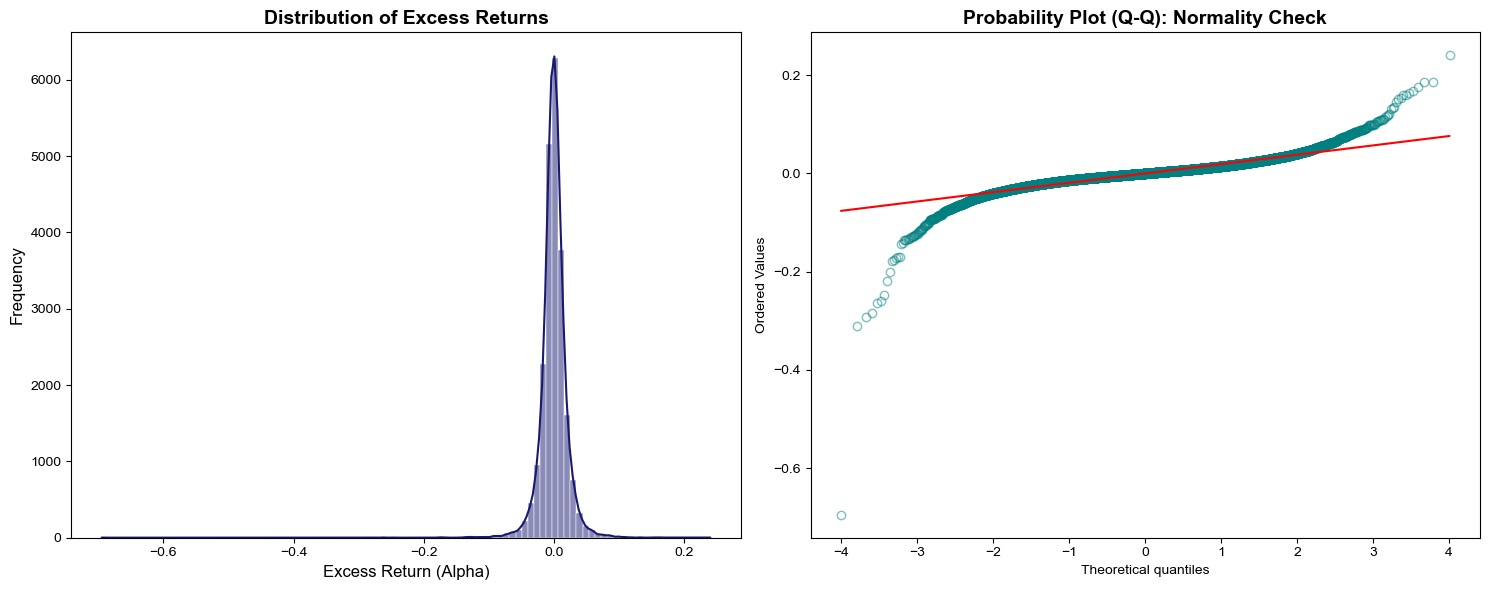

In [8]:
#Target Distribution
#Setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.set_style("white")

#Left Plot: Histogram vs Normal Distribution
sns.histplot(cleaned_df['Excess_Return'], kde=True, color='midnightblue', bins=100, ax=ax1)
ax1.set_title('Distribution of Excess Returns', fontsize=14, fontweight='bold')
ax1.set_xlabel('Excess Return (Alpha)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)

#Right Plot: Q-Q Plot (Quantile-Quantile)
#This proves that outliers deviate from a normal distribution
stats.probplot(cleaned_df['Excess_Return'].dropna(), dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('none')
ax2.get_lines()[0].set_markeredgecolor('teal')
ax2.get_lines()[0].set_alpha(0.5)
ax2.set_title('Probability Plot (Q-Q): Normality Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

To assess the statistical properties of the primary dependent variable (Excess Returns), we employed a histogram with an overlaid kernel density estimate (KDE) and a Quantile-Quantile (Q-Q) probability plot. The histogram visualizes the distribution’s shape, skewness, and peak. The Q-Q plot compares the empirical distribution of returns against a theoretical normal distribution by plotting their respective quantiles. This dual visualization is essential to verify if the data exhibits "fat tails" (leptokurtosis) a common characteristic of financial time series where extreme price movements occur more frequently than standard normal models predict.

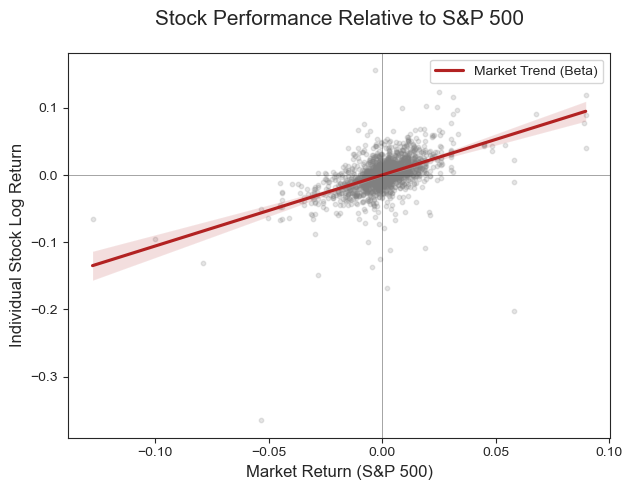

In [9]:
#Market vs. Stock Scatter Plot
#Sample for visualization, too many points will make the scatter plot ineffective.
sample_data = cleaned_df.sample(min(2000, len(cleaned_df)))

plt.figure(figsize=(7, 5))
sns.set_style("ticks")

#Regression Plot
sns.regplot(x='Market_Return', y='Log_Return', data=sample_data, 
            scatter_kws={'alpha':0.2, 'color':'gray', 's':10}, 
            line_kws={'color':'firebrick', 'label':'Market Trend (Beta)'})

#Labels and Aesthetics
plt.title('Stock Performance Relative to S&P 500', fontsize=15, pad=20)
plt.xlabel('Market Return (S&P 500)', fontsize=12)
plt.ylabel('Individual Stock Log Return', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.5)
plt.legend()
plt.show()

This visualization utilizes a scatter plot combined with a linear regression line to analyze the relationship between systematic market risk and individual stock performance. The independent variable ($X$-axis) is the S&P 500 Market Return, and the dependent variable ($Y$-axis) is the individual stock’s Log Return. The red regression line represents the stock’s market trend. In this framework, the distance of any individual data point from the regression line corresponds to the Excess Return. 

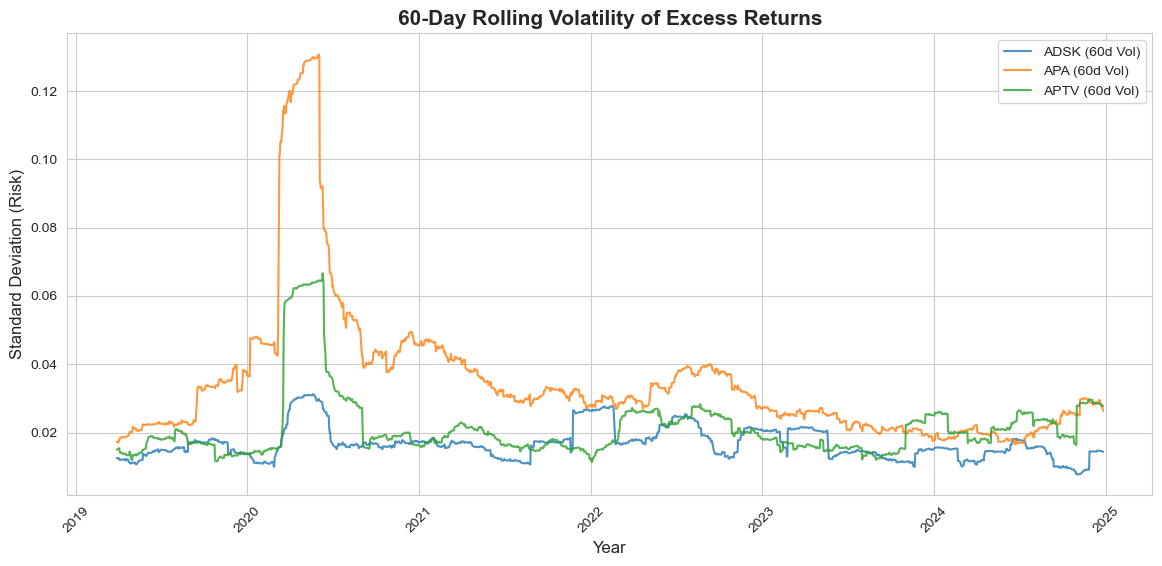

In [10]:
#Time-Series Volatility Line Chart
#Calculates the Rolling Standard Deviation
#We use a 60-day window to smooth the messiness for better storytelling
volatility_series = cleaned_df.set_index('Date').groupby('Stock_symbol')['Excess_Return'].rolling(window=60).std()
volatility_df = volatility_series.reset_index()

plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

#Plotting a representative sample
top_3_tickers = cleaned_df['Stock_symbol'].value_counts().nlargest(3).index

for ticker in top_3_tickers:
    subset = volatility_df[volatility_df['Stock_symbol'] == ticker]
    plt.plot(subset['Date'], subset['Excess_Return'], label=f'{ticker} (60d Vol)', alpha=0.8)

#Title and Legends
plt.title('60-Day Rolling Volatility of Excess Returns', fontsize=15, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Standard Deviation (Risk)', fontsize=12)
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.show()

To examine how price risk changes over time, we generated a 60-day rolling standard deviation plot of the Excess Returns for the primary tickers in the dataset. A rolling window approach was chosen over a static measure because financial volatility is not constant and tends to cluster, periods of high volatility are followed by high volatility. A 60-day window (equivalent to one trading quarter) provides a smooth representation of variance, allowing for the identification of market regimes and periods of heightened uncertainty that often coincide with significant corporate or macroeconomic announcements

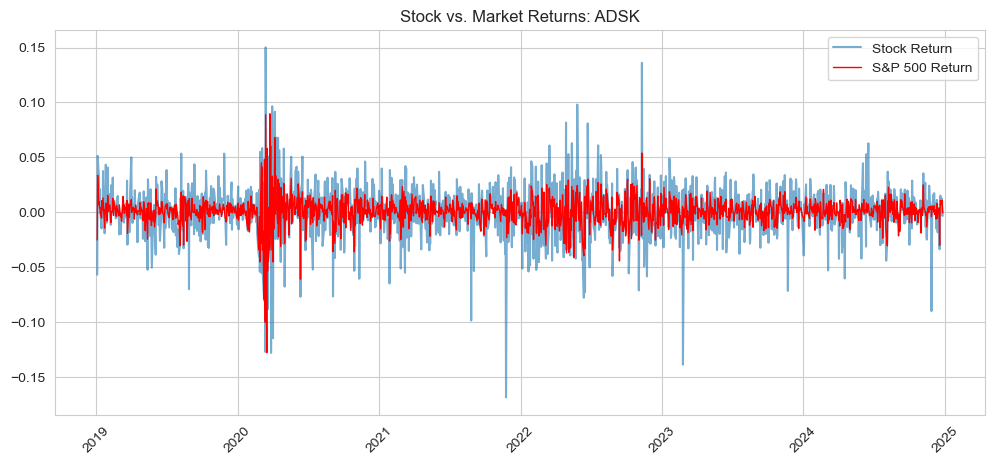

In [11]:
#The Return vs Market Dual-Line Plot
plt.figure(figsize=(12, 5))
sample_ticker = cleaned_df['Stock_symbol'].unique()[0]
data_sample = cleaned_df[cleaned_df['Stock_symbol'] == sample_ticker]

plt.plot(data_sample['Date'], data_sample['Log_Return'], label='Stock Return', alpha=0.6)
plt.plot(data_sample['Date'], data_sample['Market_Return'], label='S&P 500 Return', color='red', linewidth=1)
plt.title(f'Stock vs. Market Returns: {sample_ticker}')
plt.legend()
plt.xticks(rotation=45)
plt.show()

The gap between the blue (Stock) and red (Market) lines represents the Excess Return.

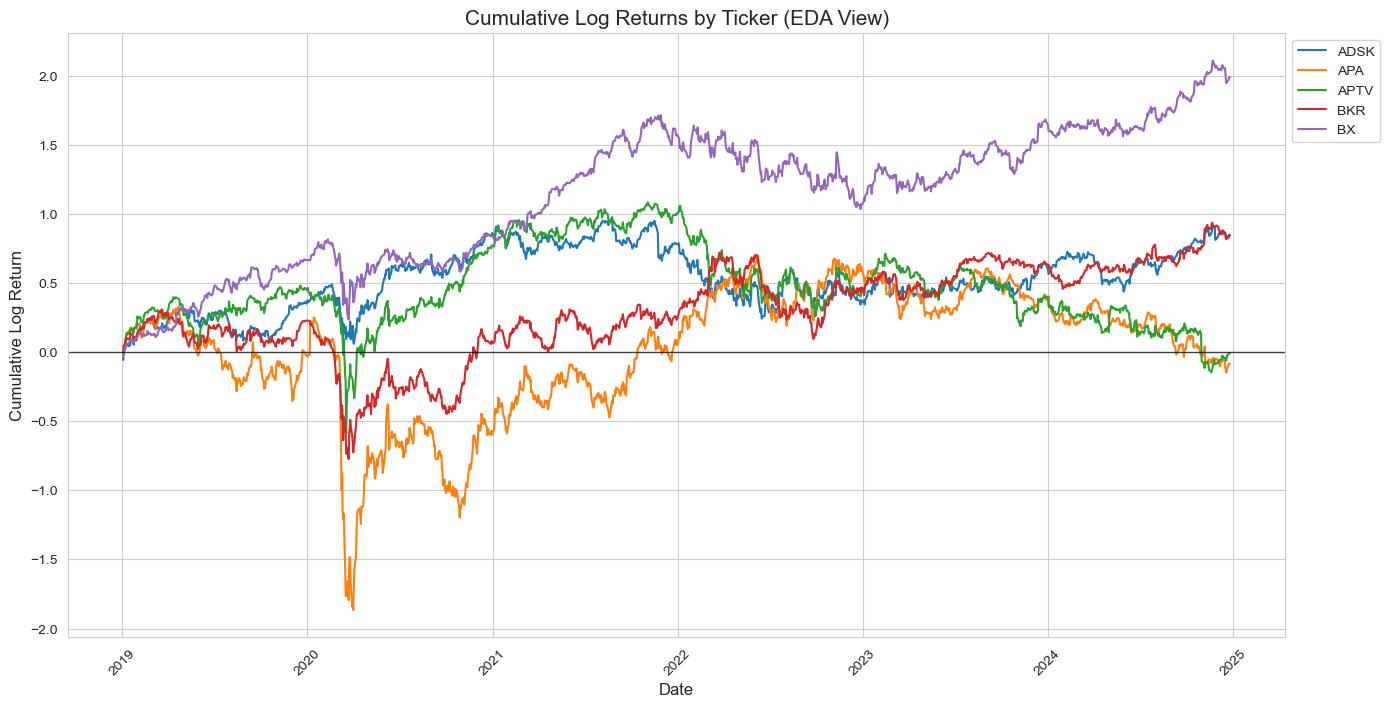

In [12]:
#Cumulative Log Return for the study period
# Using the top 5 tickers to keep the visual clean for EDA
top_tickers = cleaned_df['Stock_symbol'].value_counts().nlargest(5).index
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# 2. Plotting Cumulative Sum of Log Returns
for ticker in top_tickers:
    # Filter and ensure chronological order
    subset = cleaned_df[cleaned_df['Stock_symbol'] == ticker].sort_values('Date')
    
    # Calculate the running total of returns
    cumulative_returns = subset['Log_Return'].cumsum()
    
    plt.plot(subset['Date'], cumulative_returns, label=f'{ticker}', linewidth=1.5)

# 3. Aesthetics
plt.axhline(0, color='black', linewidth=1, alpha=0.7) # The "No Change" baseline
plt.title('Cumulative Log Returns by Ticker (EDA View)', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Log Return', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Move legend outside to declutter
plt.tight_layout()
plt.xticks(rotation=45)
plt.savefig('StudyPeriod_Price_Trend.png', dpi=300)
plt.show()

This plot illustrates the overall price trajectory during the study period (2019–2025). It also makes it it very clear which stocks underperformed their starting price by dropping below the black line. The divergence in performance is the statistical proof that company-specific factors eventually outweigh general market movements.

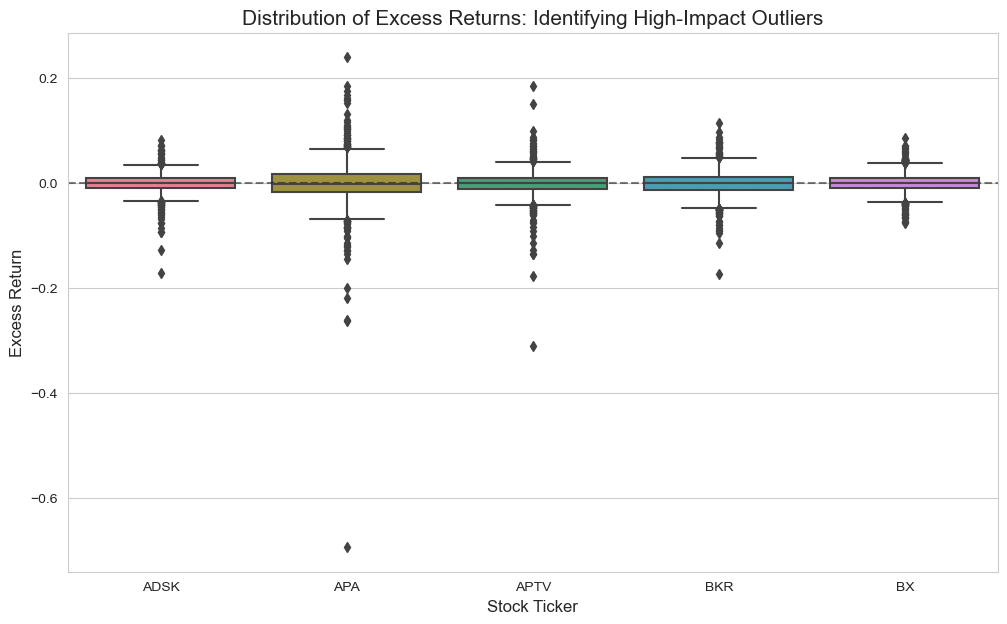

In [13]:
#Box plot for top 5 tickers to keep the visual "uncluttered."
import seaborn as sns
import matplotlib.pyplot as plt

#Top 5 tickers with the most data for a clean visual
top_tickers = cleaned_df['Stock_symbol'].value_counts().nlargest(5).index
plot_data = cleaned_df[cleaned_df['Stock_symbol'].isin(top_tickers)]

#Creating the plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = sns.boxplot(x='Stock_symbol', y='Excess_Return', data=plot_data, palette='husl')

#Adding a horizontal line at 0 to show the Neutral baseline
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

#Labels and Title
plt.title('Distribution of Excess Returns: Identifying High-Impact Outliers', fontsize=15)
plt.xlabel('Stock Ticker', fontsize=12)
plt.ylabel('Excess Return', fontsize=12)
plt.show()

The outliers dots confirm that significant price moves occur frequently, justifying the need for sentiment analysis to identify these high-impact events.

In [15]:
#Saving Cleaned File
price_path = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\Price\Price_Cleaned.csv'
cleaned_df.to_csv(price_path, index=False)